In [181]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import torch.nn as nn

In [182]:
torch.manual_seed(2020)

In [ ]:
### consider a sentence "Your journey starts with one step"
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

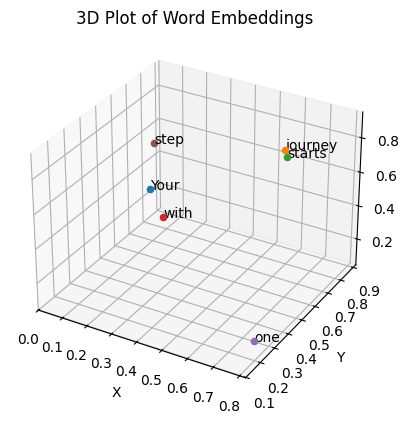

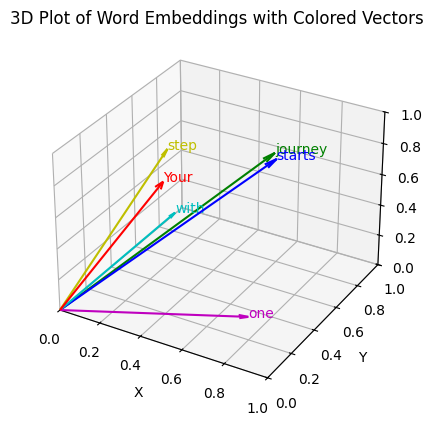

In [184]:
words = ['Your', 'journey', 'starts', 'with', 'one', 'step', 'journey-context']

x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot each point and annotate with corresponding word
for x, y, z, word in zip(x_coords, y_coords, z_coords, words):
    ax.scatter(x, y, z)
    ax.text(x, y, z, word, fontsize=10)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('3D Plot of Word Embeddings')
plt.show()

# Create 3D plot with vectors from origin to each point, using different colors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# colors to distinguish each vector
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'r']

for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    # Draw vector from origin to the point (x, y, z) with specified color and smaller arrow length ratio
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()

#### weighted Q K V  attention implementation

In [185]:
d_in=inputs.shape[1] ### dim of input embedding
d_out=5  ### output dim of contexual embedding
W_k=torch.nn.Parameter(torch.rand((d_in,d_out)))
W_q=torch.nn.Parameter(torch.rand((d_in,d_out)))
W_v=torch.nn.Parameter(torch.rand((d_in,d_out)))

In [186]:
query=inputs@W_k
key=inputs@W_q
value=inputs@W_v

In [187]:
print("Query shape =", query.shape)
print("Key shape =", key.shape)
print("Value shape =", value.shape)


Query shape = torch.Size([6, 5])
Key shape = torch.Size([6, 5])
Value shape = torch.Size([6, 5])


In [188]:
attention_score=query@key.T
d_k=torch.tensor(query.shape[1])

In [189]:
scaled_attention=torch.softmax(attention_score/torch.sqrt(d_k),dim=-1)

In [190]:
contextual_embedding=scaled_attention@value

In [191]:
contextual_embedding

tensor([[0.4205, 1.4909, 0.6960, 1.1208, 1.1226],
        [0.4294, 1.5302, 0.7153, 1.1547, 1.1516],
        [0.4287, 1.5277, 0.7141, 1.1527, 1.1498],
        [0.4111, 1.4554, 0.6788, 1.0926, 1.0962],
        [0.4058, 1.4360, 0.6685, 1.0768, 1.0821],
        [0.4188, 1.4863, 0.6942, 1.1182, 1.1190]], grad_fn=<MmBackward0>)

In [192]:
class Self_attention(nn.Module):
    def __init__(self,dim_in,dim_out):
        super().__init__()
        self.W_k=nn.Parameter(torch.rand(dim_in,dim_out))
        self.W_q=nn.Parameter(torch.rand(dim_in,dim_out))
        self.W_v=nn.Parameter(torch.rand(dim_in,dim_out))
        self.dim_key=dim_out 
    def forward(self,x):
        query= x @ self.W_q 
        key= x @ self.W_k 
        value= x @ self.W_v 
        attention_score= query @ key.T
        scaled_attention_score= torch.softmax(attention_score/torch.sqrt(torch.tensor(self.dim_key)),dim=-1)
        contextual_vector=scaled_attention_score @ value
        return contextual_vector


In [193]:
transformer_1=Self_attention(inputs.shape[1],dim_out=5)

In [195]:
cv=transformer_1(inputs)
cv

tensor([[0.7095, 0.8250, 1.0019, 0.3538, 0.7128],
        [0.7359, 0.8609, 1.0515, 0.3692, 0.7472],
        [0.7354, 0.8602, 1.0507, 0.3689, 0.7466],
        [0.6927, 0.8059, 0.9787, 0.3460, 0.6964],
        [0.7002, 0.8148, 0.9901, 0.3496, 0.7044],
        [0.7018, 0.8174, 0.9941, 0.3508, 0.7071]], grad_fn=<MmBackward0>)

In [ ]:
## nn.Linear is better than nn.param in terms of computational effieciency
class Self_attention_v2(nn.Module):

    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dim_key=d_out 

    def forward(self,x):
        key = self.W_key(x)
        query = self.W_query(x)
        value = self.W_value(x)
        attention_score= query @ key.transpose(-2, -1)
        scaled_attention_score= torch.softmax(attention_score/torch.sqrt(torch.tensor(self.dim_key)),dim=-1)
        contextual_vector=scaled_attention_score @ value
        return contextual_vector
